# Hinglish Insensitive Language Detection: RNN vs LSTM vs Bi-LSTM
This notebook trains and compares three sequential models:
- **Simple RNN** – baseline recurrent model
- **LSTM** – handles long-range dependencies better
- **Bi-LSTM** – reads text in both directions for richer context
All models are trained on the same unified, de-duplicated Hinglish dataset (~75k samples) with identical hyperparameters for a fair comparison.

## 1. Imports and Setup

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import re
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

PROJECT_DIR = '/mnt/d/Engg/dl/mini project'
# Configure GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("TF removed. Using PyTorch with CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU available, using CPU.")


TF removed. Using PyTorch with CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 2. Data Loading

We use the unified `final_no_duplicates.csv` dataset which contains cleaned and unique Hinglish samples.

In [15]:
def load_data():
    file = os.path.join(PROJECT_DIR, 'dataset_Dl.csv')
    df = pd.read_csv(file)
    
    # 1. Basic Cleaning
    df['text'] = df['text'].astype(str).str.strip()
    df.dropna(subset=['text', 'label'], inplace=True)
    df.drop_duplicates(subset=['text'], inplace=True)
    
    # 2. Filter out very short rows (< 3 words)
    df = df[df['text'].str.split().str.len() >= 3].copy()
    
    # 3. Balance Dataset (Downsampling)
    offensive_count = len(df[df['label'] == 1])
    neutral_indices = df[df['label'] == 0].index
    
    # Randomly sample neutral rows to match offensive count
    import numpy as np
    random_neutral_indices = np.random.choice(neutral_indices, offensive_count, replace=False)
    
    balanced_indices = np.concatenate([df[df['label'] == 1].index, random_neutral_indices])
    df_balanced = df.loc[balanced_indices].sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"Original samples: {len(df)}")
    print(f"Balanced samples: {len(df_balanced)}")
    print(df_balanced['label'].value_counts())
    
    return df_balanced

df = load_data()
df.head()


Original samples: 23932
Balanced samples: 14112
label
0    7056
1    7056
Name: count, dtype: int64


,text,label
0,arey reality check kar le,0
1,yaar tu har time mc harkate karta hai arey,1
2,lavde chod ke khush tho tu bhi tha ????,0
3,in our eyes should the jew only for muslim the...,0
4,arey tu bilkul bewakoof hai kya,1


## 3. Preprocessing

In [16]:
def clean_text(text):
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove Twitter Handles
    text = re.sub(r'@\w+', '', text)
    # Remove non-alphabet (keep space)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

max_words = 10000
max_len   = 50

# PyTorch Vocabulary Builder
all_words = ' '.join(df['clean_text']).split()
word_counts = Counter(all_words)
vocab = {'<PAD>': 0, '<OOV>': 1}
for word, _ in word_counts.most_common(max_words - 2):
    vocab[word] = len(vocab)

def text_to_seq(text):
    return [vocab.get(w, 1) for w in text.split()]

sequences = df['clean_text'].apply(text_to_seq)

padded_sequences = np.zeros((len(sequences), max_len), dtype=int)
for i, seq in enumerate(sequences):
    length = min(len(seq), max_len)
    padded_sequences[i, :length] = seq[:length]

labels = df['label'].values

X_train, X_val, y_train, y_val = train_test_split(
    padded_sequences, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f'Train: {X_train.shape}  |  Val: {X_val.shape}')

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TextDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TextDataset(X_val, y_val), batch_size=32, shuffle=False)


Train: (11289, 50)  |  Val: (2823, 50)


## 4. Shared Training Helpers

We define a shared evaluate function and a dict to collect results for final comparison.

In [17]:
results = {}

def train_model(model, epochs=10, patience=3):
    model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters())
    
    best_loss = float('inf')
    patience_counter = 0
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_weights = None
    
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            out = model(X_batch).squeeze()
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * X_batch.size(0)
            preds = (out > 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            
        train_loss = total_loss / total
        train_acc = correct / total
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                out = model(X_batch).squeeze()
                loss = criterion(out, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                preds = (out > 0.5).float()
                val_correct += (preds == y_batch).sum().item()
                val_total += y_batch.size(0)
                
        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        
        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")
        
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping")
                break
                
    if best_weights:
        model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})
        
    class HistoryWrapper:
        def __init__(self, history):
            self.history = history
            
    return HistoryWrapper(history)

def evaluate_model(name, model, history_wrapper):
    history = history_wrapper.history
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in val_loader:
            X_batch = X_batch.to(device)
            out = model(X_batch).squeeze()
            preds = (out > 0.5).int().cpu().numpy()
            all_preds.extend(preds)
            
    y_pred = np.array(all_preds)
    val_acc = max(history['val_accuracy'])
    val_loss = min(history['val_loss'])
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)
    
    print(f'\n========== {name} ==========')
    print(f'Val Accuracy : {val_acc:.4f}')
    print(f'Val Loss     : {val_loss:.4f}')
    print(classification_report(y_val, y_pred, target_names=['Neutral','Offensive']))
    
    results[name] = {
        'accuracy': val_acc, 'loss': val_loss, 'precision': prec,
        'recall': rec, 'f1': f1, 'history': history
    }
    
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neutral','Offensive'], yticklabels=['Neutral','Offensive'])
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()
    return results[name]


## 5. Model 1 – Simple RNN

A single `SimpleRNN` layer. Fast to train but suffers from the **vanishing gradient problem** on longer sequences.

In [18]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim1, hidden_dim2, hidden_dim3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout1 = nn.Dropout2d(0.3)
        self.rnn1 = nn.RNN(embed_dim, hidden_dim1, batch_first=True)
        self.rnn2 = nn.RNN(hidden_dim1, hidden_dim2, batch_first=True)
        self.rnn3 = nn.RNN(hidden_dim2, hidden_dim3, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim3, 128)
        self.relu = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.dropout1(x)
        x = x.permute(0, 2, 1)
        
        x, _ = self.rnn1(x)
        x, _ = self.rnn2(x)
        x, _ = self.rnn3(x)
        x = x[:, -1, :] 
        x = self.relu(self.fc1(x))
        x = self.dropout2(x)
        return self.sigmoid(self.fc2(x))

rnn_model = RNNModel(max_words, 128, 128, 64, 32).to(device)
print(rnn_model)


RNNModel(
  (embedding): Embedding(10000, 128)
  (dropout1): Dropout2d(p=0.3, inplace=False)
  (rnn1): RNN(128, 128, batch_first=True)
  (rnn2): RNN(128, 64, batch_first=True)
  (rnn3): RNN(64, 32, batch_first=True)
  (fc1): Linear(in_features=32, out_features=128, bias=True)
  (relu): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


/home/parthu/miniconda3/envs/tf_cuda/lib/python3.10/site-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


Epoch 1/30 - loss: 0.6906 - accuracy: 0.5245 - val_loss: 0.6886 - val_accuracy: 0.5282
Epoch 2/30 - loss: 0.6864 - accuracy: 0.5272 - val_loss: 0.6883 - val_accuracy: 0.5292
Epoch 3/30 - loss: 0.6832 - accuracy: 0.5288 - val_loss: 0.6895 - val_accuracy: 0.5285
Epoch 4/30 - loss: 0.6786 - accuracy: 0.5379 - val_loss: 0.6933 - val_accuracy: 0.5250
Epoch 5/30 - loss: 0.6755 - accuracy: 0.5376 - val_loss: 0.6969 - val_accuracy: 0.5225
Epoch 6/30 - loss: 0.6695 - accuracy: 0.5458 - val_loss: 0.7071 - val_accuracy: 0.5182
Epoch 7/30 - loss: 0.6634 - accuracy: 0.5465 - val_loss: 0.7195 - val_accuracy: 0.5236
Early stopping

========== Simple RNN ==========
Val Accuracy : 0.5292
Val Loss     : 0.6883
              precision    recall  f1-score   support

     Neutral       0.52      0.95      0.67      1412
   Offensive       0.68      0.11      0.19      1411

    accuracy                           0.53      2823
   macro avg       0.60      0.53      0.43      2823
weighted avg       0.60   

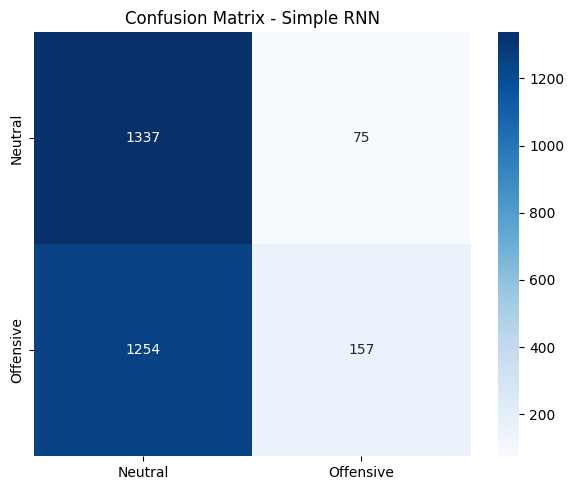

{'accuracy': 0.5292242295430393,
 'loss': 0.6883271487097853,
 'precision': 0.6767241379310345,
 'recall': 0.111268603827073,
 'f1': 0.19111381618989653,
 'history': {'loss': [0.6905922690868926,
   0.6864084692797128,
   0.6831908013497731,
   0.6785774885557426,
   0.6755313668220203,
   0.6695492949506053,
   0.6633651690145603],
  'accuracy': [0.5244928691646735,
   0.5271503233235894,
   0.528833377624236,
   0.5378687217645496,
   0.537602976348658,
   0.5458410842412968,
   0.5464611568783772],
  'val_loss': [0.6885540378334418,
   0.6883271487097853,
   0.6895182992691611,
   0.6933099873894459,
   0.6969196220640168,
   0.7071280458739494,
   0.7195308837872044],
  'val_accuracy': [0.5281615302869288,
   0.5292242295430393,
   0.528515763372299,
   0.5249734325185972,
   0.5224938009210061,
   0.518243003896564,
   0.5235565001771165]}}

In [19]:
history_rnn = train_model(rnn_model, epochs=30, patience=5)
evaluate_model('Simple RNN', rnn_model, history_rnn)

## 6. Model 2 – LSTM

Stacked `LSTM` layers with **gating mechanisms** that solve the vanishing gradient problem and capture long-range dependencies.

In [20]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim1, hidden_dim2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout1 = nn.Dropout2d(0.3)
        self.lstm1 = nn.LSTM(embed_dim, hidden_dim1, batch_first=True)
        self.lstm2 = nn.LSTM(hidden_dim1, hidden_dim2, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim2, 128)
        self.relu = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.dropout1(x)
        x = x.permute(0, 2, 1)
        
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = x[:, -1, :] 
        x = self.relu(self.fc1(x))
        x = self.dropout2(x)
        return self.sigmoid(self.fc2(x))

lstm_model = LSTMModel(max_words, 128, 128, 64).to(device)
print(lstm_model)


LSTMModel(
  (embedding): Embedding(10000, 128)
  (dropout1): Dropout2d(p=0.3, inplace=False)
  (lstm1): LSTM(128, 128, batch_first=True)
  (lstm2): LSTM(128, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (relu): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


/home/parthu/miniconda3/envs/tf_cuda/lib/python3.10/site-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


Epoch 1/30 - loss: 0.6893 - accuracy: 0.5256 - val_loss: 0.6878 - val_accuracy: 0.5296
Epoch 2/30 - loss: 0.6863 - accuracy: 0.5282 - val_loss: 0.6866 - val_accuracy: 0.5296
Epoch 3/30 - loss: 0.6720 - accuracy: 0.5623 - val_loss: 0.5124 - val_accuracy: 0.7800
Epoch 4/30 - loss: 0.3891 - accuracy: 0.8485 - val_loss: 0.2441 - val_accuracy: 0.9044
Epoch 5/30 - loss: 0.2208 - accuracy: 0.9206 - val_loss: 0.2084 - val_accuracy: 0.9267
Epoch 6/30 - loss: 0.1819 - accuracy: 0.9398 - val_loss: 0.1815 - val_accuracy: 0.9348
Epoch 7/30 - loss: 0.1549 - accuracy: 0.9484 - val_loss: 0.1784 - val_accuracy: 0.9391
Epoch 8/30 - loss: 0.1295 - accuracy: 0.9584 - val_loss: 0.1644 - val_accuracy: 0.9447
Epoch 9/30 - loss: 0.1070 - accuracy: 0.9639 - val_loss: 0.1684 - val_accuracy: 0.9462
Epoch 10/30 - loss: 0.0875 - accuracy: 0.9712 - val_loss: 0.1689 - val_accuracy: 0.9458
Epoch 11/30 - loss: 0.0757 - accuracy: 0.9731 - val_loss: 0.1928 - val_accuracy: 0.9440
Epoch 12/30 - loss: 0.0633 - accuracy: 0.

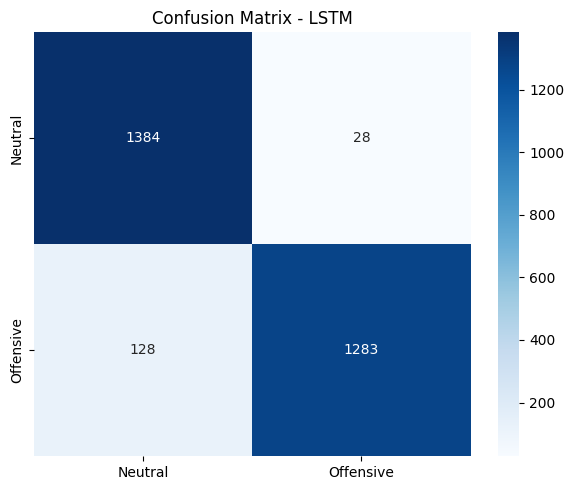

{'accuracy': 0.9461565710237336,
 'loss': 0.16437089602617014,
 'precision': 0.9786422578184591,
 'recall': 0.9092841956059532,
 'f1': 0.9426891991182953,
 'history': {'loss': [0.6892942026757785,
   0.6862903692152303,
   0.6720384592466754,
   0.3891321813638348,
   0.2208174988290841,
   0.18191088018916624,
   0.1548505179126656,
   0.12948919964439634,
   0.10695278375023534,
   0.0875094176141948,
   0.07566749340370238,
   0.06326827967854738,
   0.05978532063680139],
  'accuracy': [0.5255558508282399,
   0.5282133049871557,
   0.5623173000265745,
   0.8485251129418018,
   0.920630702453716,
   0.9397643723979094,
   0.9484453893170343,
   0.9583665515103198,
   0.9639472052440429,
   0.9712109132784126,
   0.9730711311896536,
   0.9799805120028346,
   0.9802462574187262],
  'val_loss': [0.6878499677744564,
   0.6865869445282223,
   0.5124142013286979,
   0.244062208354452,
   0.20835584967937867,
   0.18151975991854294,
   0.1784189893523303,
   0.16437089602617014,
   0.168391

In [21]:
history_lstm = train_model(lstm_model, epochs=30, patience=5)
evaluate_model('LSTM', lstm_model, history_lstm)

## 7. Model 3 – Bidirectional LSTM (Bi-LSTM)

Wraps LSTM in a `Bidirectional` wrapper so the model reads the sequence **forward and backward**, doubling the contextual information available at each time step.

In [22]:
class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim1, hidden_dim2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout1 = nn.Dropout2d(0.2)
        self.lstm1 = nn.LSTM(embed_dim, hidden_dim1, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(hidden_dim1*2, hidden_dim2, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(hidden_dim2*2, 128)
        self.relu = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.dropout1(x)
        x = x.permute(0, 2, 1)
        
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = x[:, -1, :] 
        x = self.relu(self.fc1(x))
        x = self.dropout2(x)
        return self.sigmoid(self.fc2(x))

bilstm_model = BiLSTMModel(max_words, 128, 128, 64).to(device)
print(bilstm_model)


BiLSTMModel(
  (embedding): Embedding(10000, 128)
  (dropout1): Dropout2d(p=0.2, inplace=False)
  (lstm1): LSTM(128, 128, batch_first=True, bidirectional=True)
  (lstm2): LSTM(256, 64, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (relu): ReLU()
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


/home/parthu/miniconda3/envs/tf_cuda/lib/python3.10/site-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  return F.dropout2d(input, self.p, self.training, self.inplace)


Epoch 1/30 - loss: 0.6887 - accuracy: 0.5237 - val_loss: 0.6888 - val_accuracy: 0.5282
Epoch 2/30 - loss: 0.6840 - accuracy: 0.5327 - val_loss: 0.6889 - val_accuracy: 0.5236
Epoch 3/30 - loss: 0.6774 - accuracy: 0.5343 - val_loss: 0.6896 - val_accuracy: 0.5296
Epoch 4/30 - loss: 0.5890 - accuracy: 0.6495 - val_loss: 0.3830 - val_accuracy: 0.8633
Epoch 5/30 - loss: 0.2656 - accuracy: 0.9065 - val_loss: 0.2444 - val_accuracy: 0.9196
Epoch 6/30 - loss: 0.1728 - accuracy: 0.9443 - val_loss: 0.1917 - val_accuracy: 0.9430
Epoch 7/30 - loss: 0.1354 - accuracy: 0.9594 - val_loss: 0.1835 - val_accuracy: 0.9440
Epoch 8/30 - loss: 0.1061 - accuracy: 0.9672 - val_loss: 0.2142 - val_accuracy: 0.9440
Epoch 9/30 - loss: 0.0808 - accuracy: 0.9747 - val_loss: 0.2062 - val_accuracy: 0.9454
Epoch 10/30 - loss: 0.0623 - accuracy: 0.9791 - val_loss: 0.3016 - val_accuracy: 0.9419
Epoch 11/30 - loss: 0.0465 - accuracy: 0.9837 - val_loss: 0.2984 - val_accuracy: 0.9465
Epoch 12/30 - loss: 0.0376 - accuracy: 0.

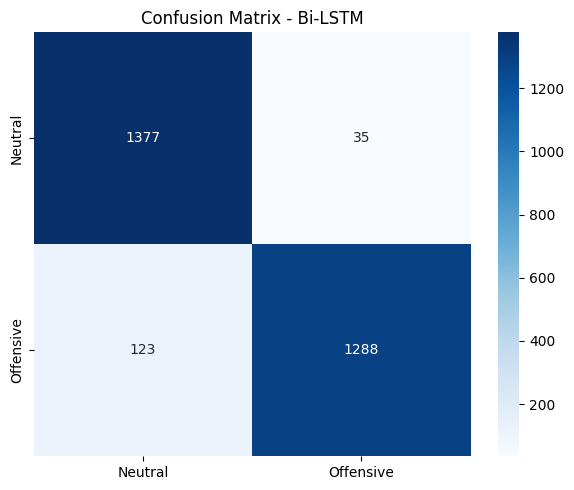

{'accuracy': 0.9486362026213249,
 'loss': 0.1835183473927435,
 'precision': 0.9735449735449735,
 'recall': 0.9128277817150957,
 'f1': 0.9422092172640819,
 'history': {'loss': [0.6887401221060163,
   0.6840463199209138,
   0.6774402949277605,
   0.5889788299405614,
   0.2656381610477031,
   0.1727675864992229,
   0.13541109651816843,
   0.10611081023793181,
   0.08079802529058577,
   0.06233059314735196,
   0.046526226667113604,
   0.0376154140716364],
  'accuracy': [0.5236956329169988,
   0.5327309770573124,
   0.5343254495526619,
   0.6494817964390114,
   0.9064576136061653,
   0.9442820444680663,
   0.9594295331738861,
   0.967224732040039,
   0.9746656036850031,
   0.9790946939498627,
   0.9837009478253167,
   0.9885729471166622],
  'val_loss': [0.6888072534397989,
   0.6888653079837592,
   0.6895782357828016,
   0.3830287439410162,
   0.24436067263792052,
   0.19166814582834757,
   0.1835183473927435,
   0.21419106420555775,
   0.20624439553181162,
   0.30156351382581215,
   0.2983

In [23]:
history_bilstm = train_model(bilstm_model, epochs=30, patience=5)
evaluate_model('Bi-LSTM', bilstm_model, history_bilstm)

## 8. Model Comparison

Side-by-side visualisation of all four key metrics across the three models.

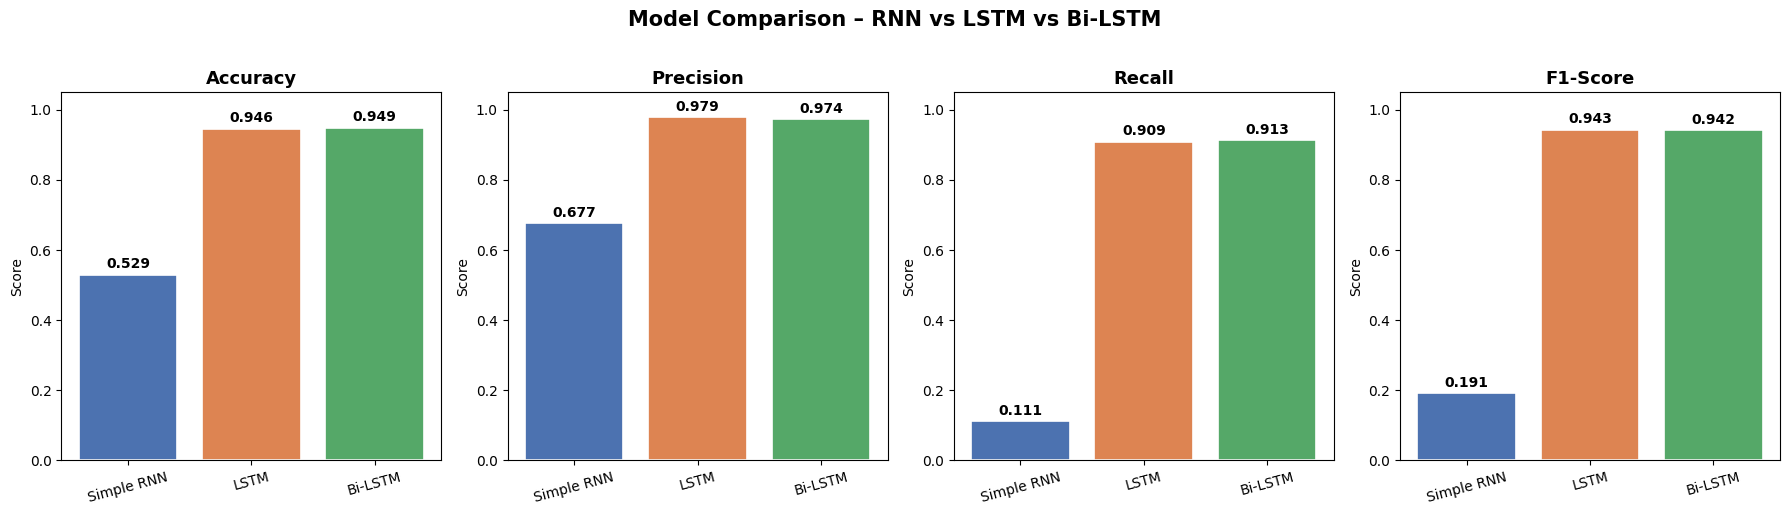

Saved → model_comparison_bars.png


In [24]:
# ── Bar chart comparison ──────────────────────────────────────────────────
models  = list(results.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1']
labels_m = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Model Comparison – RNN vs LSTM vs Bi-LSTM', fontsize=15, fontweight='bold', y=1.02)

for ax, metric, label in zip(axes, metrics, labels_m):
    vals = [results[m][metric] for m in models]
    bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'model_comparison_bars.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → model_comparison_bars.png')

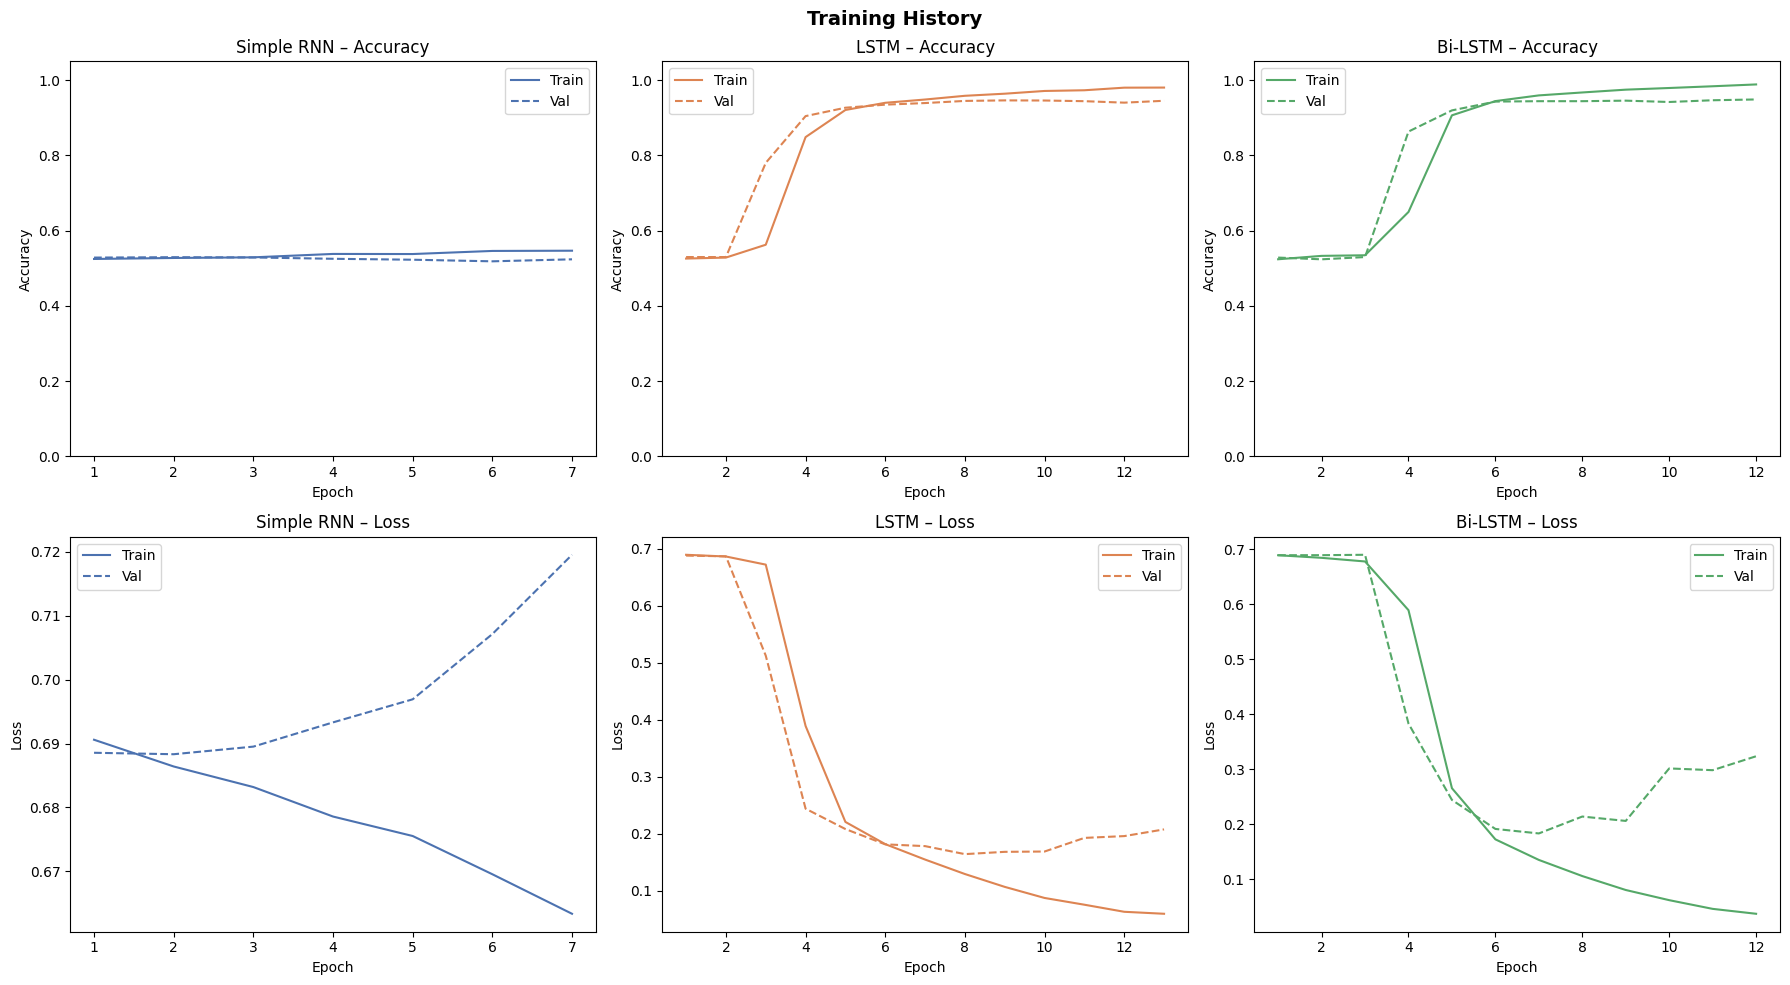

Saved → training_curves.png


In [25]:
# ── Training curves per model ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

for col, (name, color) in enumerate(zip(models, colors)):
    h = results[name]['history']
    epochs = range(1, len(h['loss'])+1)

    # Accuracy
    axes[0][col].plot(epochs, h['accuracy'],     label='Train', color=color)
    axes[0][col].plot(epochs, h['val_accuracy'], label='Val',   color=color, linestyle='--')
    axes[0][col].set_title(f'{name} – Accuracy')
    axes[0][col].set_xlabel('Epoch'); axes[0][col].set_ylabel('Accuracy')
    axes[0][col].legend()
    axes[0][col].set_ylim(0, 1.05)

    # Loss
    axes[1][col].plot(epochs, h['loss'],     label='Train', color=color)
    axes[1][col].plot(epochs, h['val_loss'], label='Val',   color=color, linestyle='--')
    axes[1][col].set_title(f'{name} – Loss')
    axes[1][col].set_xlabel('Epoch'); axes[1][col].set_ylabel('Loss')
    axes[1][col].legend()

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → training_curves.png')

In [26]:
# ── Summary table ────────────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Model'    : models,
    'Accuracy' : [results[m]['accuracy']  for m in models],
    'Precision': [results[m]['precision'] for m in models],
    'Recall'   : [results[m]['recall']    for m in models],
    'F1-Score' : [results[m]['f1']        for m in models],
    'Val Loss' : [results[m]['loss']      for m in models],
}).set_index('Model')

print('\n====== Final Comparison Table ======')
print(summary_df.to_string(float_format=lambda x: f'{x:.4f}'))
summary_df.style.highlight_max(axis=0, color='lightgreen').highlight_min(subset=['Val Loss'], axis=0, color='lightgreen')


====== Final Comparison Table ======
            Accuracy  Precision  Recall  F1-Score  Val Loss
Model                                                      
Simple RNN    0.5292     0.6767  0.1113    0.1911    0.6883
LSTM          0.9462     0.9786  0.9093    0.9427    0.1644
Bi-LSTM       0.9486     0.9735  0.9128    0.9422    0.1835


,Accuracy,Precision,Recall,F1-Score,Val Loss
Model,,,,,
Simple RNN,0.529224,0.676724,0.111269,0.191114,0.688327
LSTM,0.946157,0.978642,0.909284,0.942689,0.164371
Bi-LSTM,0.948636,0.973545,0.912828,0.942209,0.183518
